# Full Autonomous RAG Loop [Step 04 - Autonomous Loop]

> **MLCourse - Agentic AI - Autonomous RAG**

The ultimate goal of autonomous RAG is a graph that decides, at every step,
what to do next -- retrieve, re-retrieve with a different strategy, or answer.
There is no fixed pipeline; the LLM controls the entire flow.  This notebook
combines self-routing, self-correction, and a loop that can re-retrieve when
the initial context is insufficient.

### What you will learn

1. How to build an autonomous loop where the LLM decides every transition.
2. How to switch retrieval strategies mid-loop (vector <-> BM25).
3. How to detect when context is insufficient and re-retrieve.
4. How iteration guards and early-exit conditions keep the loop bounded.
5. How to inspect the full decision log after each run.

## 1. Setup

In [1]:
from pathlib import Path
import os
import re
import warnings
warnings.filterwarnings("ignore")

def find_track(start: Path, target: str = "03_agentic_ai") -> Path:
    """Climb parent folders until the track directory appears."""
    for candidate in [start, *start.parents]:
        probe = candidate / target
        if probe.is_dir():
            return probe
    raise FileNotFoundError(f"Could not find '{target}' above {start}")

TRACK = find_track(Path.cwd())
DATA = TRACK / "data"
DATA.mkdir(exist_ok=True)

from dotenv import load_dotenv
load_dotenv()
load_dotenv(TRACK / ".env")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("[setup] TRACK:", TRACK)
print("[setup] DATA :", DATA)

[setup] TRACK: D:\projects\python\MLCourse\03_agentic_ai
[setup] DATA : D:\projects\python\MLCourse\03_agentic_ai\data


## 2. Ingest Alice and Build Both Retrievers

In [2]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever

ALICE_PATH = DATA / "alice.txt"
raw_text = ALICE_PATH.read_text(encoding="utf-8-sig")[:20_000]

marks = list(re.finditer(r"^CHAPTER [IVX]+\.", raw_text, flags=re.MULTILINE))
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

documents = []
for i, mark in enumerate(marks):
    seg_end = marks[i + 1].start() if i + 1 < len(marks) else len(raw_text)
    for piece in splitter.split_text(raw_text[mark.start():seg_end]):
        documents.append(Document(
            page_content=piece,
            metadata={"source": "alice", "chapter": str(i + 1), "chunk_id": len(documents)},
        ))

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectordb = FAISS.from_documents(documents, embeddings)
vector_retriever = vectordb.as_retriever(search_kwargs={"k": 4})
bm25_retriever = BM25Retriever.from_documents(documents, k=4)
print(f"[ingest] chunks: {len(documents)} | vector + BM25 retrievers ready")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[ingest] chunks: 60 | vector + BM25 retrievers ready


## 3. Initialize the LLM

In [3]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.1:8b", temperature=0)
print("[llm] ChatOllama ready:", llm.model)

[llm] ChatOllama ready: llama3.1:8b


## 4. Define the State
The state is the full working memory of the autonomous agent.  It tracks the
query, accumulated context, current answer, evaluation verdict, which strategy
to use next, the decision log, and iteration counters.

In [4]:
from typing import TypedDict

class AutoRAGState(TypedDict):
    query: str                       # original user question
    context: str                     # accumulated retrieved text
    answer: str                      # current best answer
    next_action: str                 # "retrieve_vector", "retrieve_bm25", "answer", "done"
    strategy_used: list              # strategies tried so far
    verdict: str                     # "pass" or "fail"
    issues: list                     # evaluation issues
    decision_log: list               # full log of every decision
    iteration: int                   # loop counter
    max_iterations: int              # hard cap

print("[state] AutoRAGState defined")

[state] AutoRAGState defined


## 5. Planner Node
The planner is the brain of the autonomous loop.  It reads the current state
and decides the next action.  On the first call it picks a retrieval strategy;
on subsequent calls it decides whether to re-retrieve or answer.

In [5]:
def plan_next_action(state: AutoRAGState) -> dict:
    """Decide what to do next: retrieve, re-retrieve, or answer."""
    from langchain_core.prompts import ChatPromptTemplate

    iteration = state.get("iteration", 0)
    strategies = state.get("strategy_used", [])
    verdict = state.get("verdict", "")
    issues = state.get("issues", [])
    context = state.get("context", "")
    answer = state.get("answer", "")

    # First iteration: pick a retrieval strategy
    if iteration == 0:
        prompt = ChatPromptTemplate.from_messages([
            ("system",
             "You are planning a retrieval strategy for a question about Alice in Wonderland. "
             "Choose the best strategy:\n"
             "- 'retrieve_vector' for semantic/conceptual questions\n"
             "- 'retrieve_bm25' for specific names, places, or exact phrases\n"
             "Reply with ONLY the action name."),
            ("user", "{query}")
        ])
        response = (prompt | llm).invoke({"query": state["query"]})
        action = response.content.strip().lower()
        if action not in ("retrieve_vector", "retrieve_bm25"):
            action = "retrieve_vector"
        log = state.get("decision_log", []) + [f"planner: initial strategy -> {action}"]
        print(f"  [planner] iteration {iteration}: chose {action}")
        return {"next_action": action, "decision_log": log, "iteration": iteration + 1}

    # Subsequent iterations: decide whether to re-retrieve or answer
    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are managing an autonomous RAG loop.  The current answer was evaluated "
         "and found insufficient.  Decide the next action:\n"
         "- 'retrieve_vector' if semantic search might help\n"
         "- 'retrieve_bm25' if keyword search might find better passages\n"
         "- 'answer' if we should generate the best answer from what we have\n\n"
         "Consider: what strategies have already been tried, and what issues were found."),
        ("user",
         "Query: {query}\n"
         "Tried strategies: {strategies}\n"
         "Current issues: {issues}\n"
         "Reply with ONLY the action name.")
    ])
    response = (prompt | llm).invoke({
        "query": state["query"],
        "issues": ", ".join(issues) if issues else "none",
        "strategies": ", ".join(strategies) if strategies else "none",
    })
    action = response.content.strip().lower()
    if action not in ("retrieve_vector", "retrieve_bm25", "answer"):
        action = "answer"
    log = state.get("decision_log", []) + [f"planner: iteration {iteration} -> {action}"]
    print(f"  [planner] iteration {iteration}: chose {action}")
    return {"next_action": action, "decision_log": log, "iteration": iteration + 1}

## 6. Retrieval Nodes

In [6]:
def retrieve_vector(state: AutoRAGState) -> dict:
    """Retrieve via vector similarity, append to accumulated context."""
    docs = vector_retriever.invoke(state["query"])
    new_context = "\n\n".join(
        f"[chunk {d.metadata.get('chunk_id', '?')}] {d.page_content}" for d in docs
    )
    context = state.get("context", "")
    if context:
        context = context + "\n\n---\n\n" + new_context
    else:
        context = new_context
    strategies = state.get("strategy_used", []) + ["vector"]
    log = state.get("decision_log", []) + [f"vector: retrieved {len(docs)} chunks"]
    print(f"  [vector] {len(docs)} chunks, total context: {len(context)} chars")
    return {"context": context, "strategy_used": strategies, "next_action": ""}


def retrieve_bm25(state: AutoRAGState) -> dict:
    """Retrieve via BM25 keyword search, append to accumulated context."""
    docs = bm25_retriever.invoke(state["query"])
    new_context = "\n\n".join(
        f"[chunk {d.metadata.get('chunk_id', '?')}] {d.page_content}" for d in docs
    )
    context = state.get("context", "")
    if context:
        context = context + "\n\n---\n\n" + new_context
    else:
        context = new_context
    strategies = state.get("strategy_used", []) + ["bm25"]
    log = state.get("decision_log", []) + [f"bm25: retrieved {len(docs)} chunks"]
    print(f"  [bm25] {len(docs)} chunks, total context: {len(context)} chars")
    return {"context": context, "strategy_used": strategies, "next_action": ""}

## 7. Generate Answer Node

In [7]:
def generate_answer(state: AutoRAGState) -> dict:
    """Generate an answer from accumulated context."""
    from langchain_core.prompts import ChatPromptTemplate

    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You answer questions about Alice in Wonderland using ONLY the provided context. "
         "Cite evidence by chunk id.  If the context is insufficient, say so. "
         "Keep the answer to 2-4 sentences."),
        ("user", "Question: {query}\n\nContext:\n{context}")
    ])
    response = (prompt | llm).invoke({
        "query": state["query"],
        "context": state["context"]
    })
    log = state.get("decision_log", []) + ["generate: answer produced"]
    print(f"  [generate] {len(response.content)} chars")
    return {"answer": response.content, "verdict": "", "issues": [],
            "next_action": "", "decision_log": log}

## 8. Evaluate Answer Node

In [8]:
def evaluate_answer(state: AutoRAGState) -> dict:
    """Check faithfulness of the answer against accumulated context."""
    from langchain_core.prompts import ChatPromptTemplate

    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are a strict faithfulness evaluator.  Given the RETRIEVED CONTEXT and "
         "the GENERATED ANSWER, check:\n"
         "1. Every factual claim in the answer is supported by the context.\n"
         "2. The answer does not add unsupported information.\n"
         "3. The answer does not contradict the context.\n\n"
         "Reply in EXACTLY this format:\n"
         "VERDICT: pass or fail\n"
         "ISSUES: list each issue with a dash, or 'none' if pass"),
        ("user", "CONTEXT:\n{context}\n\nANSWER:\n{answer}")
    ])
    from langchain_core.output_parsers import StrOutputParser
    result = (prompt | llm | StrOutputParser()).invoke({
        "context": state["context"],
        "answer": state["answer"]
    })

    verdict_match = re.search(r"VERDICT:\s*(pass|fail)", result, re.IGNORECASE)
    verdict = verdict_match.group(1).lower() if verdict_match else "fail"

    issues = []
    if verdict == "fail":
        issues_section = re.search(r"ISSUES:\s*(.+)", result, re.IGNORECASE | re.DOTALL)
        if issues_section:
            raw = issues_section.group(1).strip()
            issues = [line.lstrip("- ").strip() for line in raw.split("\n")
                      if line.strip() and line.strip().lower() != "none"]

    log = state.get("decision_log", []) + [f"evaluate: {verdict} ({len(issues)} issues)"]
    print(f"  [evaluate] verdict: {verdict} | issues: {len(issues)}")
    return {"verdict": verdict, "issues": issues, "decision_log": log,
            "next_action": ""}

## 9. Routing Logic
The router reads `next_action` after the planner and after evaluation.
If the planner says "done" or evaluation passes, we end.  If the iteration
guard trips, we also end.

In [9]:
def route_by_action(state: AutoRAGState) -> str:
    """Route based on the planner's decision or evaluation result."""
    iteration = state.get("iteration", 0)
    max_iter = state.get("max_iterations", 5)

    # Iteration guard
    if iteration > max_iter:
        print(f"  [router] max iterations ({max_iter}) reached -> END")
        return "end"

    # If evaluation just passed, end
    if state.get("verdict") == "pass":
        print("  [router] answer passed -> END")
        return "end"

    action = state.get("next_action", "answer")
    if action in ("retrieve_vector", "retrieve_bm25"):
        return action
    return "answer"

## 10. Build the Autonomous Loop Graph
The planner node sits at the top.  After every retrieval or answer generation,
the evaluator fires.  The evaluator's verdict feeds back to the planner, which
decides whether to loop or stop.

In [10]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(AutoRAGState)

# Nodes
graph.add_node("planner", plan_next_action)
graph.add_node("retrieve_vector", retrieve_vector)
graph.add_node("retrieve_bm25", retrieve_bm25)
graph.add_node("generate", generate_answer)
graph.add_node("evaluate", evaluate_answer)

# Entry
graph.add_edge(START, "planner")

# Planner routes to retrieval or generation
graph.add_conditional_edges(
    "planner",
    route_by_action,
    {
        "retrieve_vector": "retrieve_vector",
        "retrieve_bm25": "retrieve_bm25",
        "answer": "generate",
        "end": END,
    }
)

# Retrieval feeds into generation
graph.add_edge("retrieve_vector", "generate")
graph.add_edge("retrieve_bm25", "generate")

# Generation feeds into evaluation
graph.add_edge("generate", "evaluate")

# Evaluation feeds back into planner (the loop)
graph.add_edge("evaluate", "planner")

app = graph.compile()
print("[graph] autonomous RAG loop compiled")

[graph] autonomous RAG loop compiled


## 11. Visualize the Graph

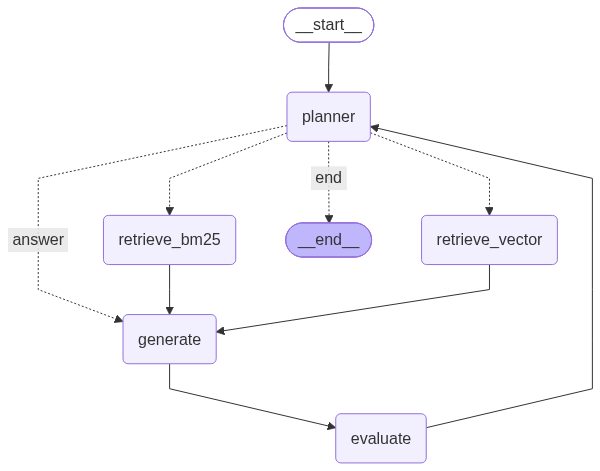

In [11]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print("Graph structure:")
    print("  START -> planner")
    print("    planner -> retrieve_vector -> generate -> evaluate -> planner")
    print("    planner -> retrieve_bm25   -> generate -> evaluate -> planner")
    print("    planner -> generate         -> evaluate -> planner")
    print("    planner -> END              (done or max iterations)")
    print("    evaluate -> planner         (loop back)")

## 12. Test: Simple Question (should answer in one pass)

In [12]:
print("=" * 60)
print("TEST 1: Simple question")
print("=" * 60)
result = app.invoke({
    "query": "Who is Alice?",
    "context": "",
    "answer": "",
    "next_action": "",
    "strategy_used": [],
    "verdict": "",
    "issues": [],
    "decision_log": [],
    "iteration": 0,
    "max_iterations": 3,
})
print(f"\nAnswer: {result['answer'][:400]}")
print(f"Verdict: {result['verdict']}")
print(f"Iterations: {result['iteration']}")
print(f"Strategies tried: {result['strategy_used']}")
print(f"Decision log:")
for entry in result["decision_log"]:
    print(f"  {entry}")

TEST 1: Simple question


  [planner] iteration 0: chose retrieve_bm25
  [bm25] 4 chunks, total context: 1687 chars


  [generate] 280 chars


  [evaluate] verdict: fail | issues: 2


  [planner] iteration 1: chose retrieve_vector
  [vector] 4 chunks, total context: 3203 chars


  [generate] 342 chars


  [evaluate] verdict: pass | issues: 0


  [planner] iteration 2: chose retrieve_vector
  [router] answer passed -> END

Answer: The context does not provide a clear answer to who Alice is beyond her being a curious child. However, it can be inferred that she is likely a young girl based on her age and behavior (chunk 7). She also seems to have a tendency to pretend to be two people at times (chunk 30), which suggests that she may be prone to imagination and fantasy.
Verdict: pass
Iterations: 3
Strategies tried: ['bm25', 'vector']
Decision log:
  planner: initial strategy -> retrieve_bm25
  generate: answer produced
  evaluate: fail (2 issues)
  planner: iteration 1 -> retrieve_vector
  generate: answer produced
  evaluate: pass (0 issues)
  planner: iteration 2 -> retrieve_vector


## 13. Test: Hard Question (may trigger re-retrieval)

In [13]:
print("=" * 60)
print("TEST 2: Hard question that may need multiple retrieval rounds")
print("=" * 60)
result = app.invoke({
    "query": "What specific items did the Mad Hatter and the March Hare do at the tea party that frustrated Alice?",
    "context": "",
    "answer": "",
    "next_action": "",
    "strategy_used": [],
    "verdict": "",
    "issues": [],
    "decision_log": [],
    "iteration": 0,
    "max_iterations": 3,
})
print(f"\nAnswer: {result['answer'][:400]}")
print(f"Verdict: {result['verdict']}")
print(f"Iterations: {result['iteration']}")
print(f"Strategies tried: {result['strategy_used']}")
print(f"Decision log:")
for entry in result["decision_log"]:
    print(f"  {entry}")

TEST 2: Hard question that may need multiple retrieval rounds


  [planner] iteration 0: chose retrieve_vector
  [vector] 4 chunks, total context: 1932 chars


  [generate] 311 chars


  [evaluate] verdict: pass | issues: 0


  [planner] iteration 1: chose retrieve_bm25
  [router] answer passed -> END

Answer: The context does not mention the Mad Hatter and the March Hare at a tea party that frustrated Alice. The provided chunks describe Alice's adventures in Wonderland, including her encounter with the White Rabbit (chunk 41), her attempt to reach the little golden key (chunk 28), and her growth in size (chunk 39).
Verdict: pass
Iterations: 2
Strategies tried: ['vector']
Decision log:
  planner: initial strategy -> retrieve_vector
  generate: answer produced
  evaluate: pass (0 issues)
  planner: iteration 1 -> retrieve_bm25


## 14. Test: Out-of-Corpus Question

In [14]:
print("=" * 60)
print("TEST 3: Out-of-corpus question")
print("=" * 60)
result = app.invoke({
    "query": "What is the capital of France?",
    "context": "",
    "answer": "",
    "next_action": "",
    "strategy_used": [],
    "verdict": "",
    "issues": [],
    "decision_log": [],
    "iteration": 0,
    "max_iterations": 3,
})
print(f"\nAnswer: {result['answer'][:400]}")
print(f"Verdict: {result['verdict']}")
print(f"Iterations: {result['iteration']}")
print(f"Decision log:")
for entry in result["decision_log"]:
    print(f"  {entry}")

TEST 3: Out-of-corpus question


  [planner] iteration 0: chose retrieve_bm25
  [bm25] 4 chunks, total context: 1544 chars


  [generate] 201 chars


  [evaluate] verdict: pass | issues: 0


  [planner] iteration 1: chose retrieve_vector
  [router] answer passed -> END

Answer: There is no mention of France or its capital in the provided context. The text only discusses Alice's thoughts and adventures in Wonderland, with no reference to geography outside of Wonderland itself.
Verdict: pass
Iterations: 2
Decision log:
  planner: initial strategy -> retrieve_bm25
  generate: answer produced
  evaluate: pass (0 issues)
  planner: iteration 1 -> retrieve_vector


## 15. Inspect Graph Structure

In [15]:
print("=== Graph Structure ===")
g = app.get_graph()
print(f"Nodes: {list(g.nodes.keys())}")
print(f"Edges:")
for edge in g.edges:
    print(f"  {edge.source} -> {edge.target}")

=== Graph Structure ===
Nodes: ['__start__', 'planner', 'retrieve_vector', 'retrieve_bm25', 'generate', 'evaluate', '__end__']
Edges:
  __start__ -> planner
  evaluate -> planner
  generate -> evaluate
  planner -> __end__
  planner -> generate
  planner -> retrieve_bm25
  planner -> retrieve_vector
  retrieve_bm25 -> generate
  retrieve_vector -> generate


## Summary

Key takeaways:
- The planner node is the brain: it decides every transition at runtime.
- The loop is: plan -> retrieve/generate -> evaluate -> plan -> ...
- Multiple retrieval strategies can be tried in sequence within one run.
- The evaluator detects hallucinations and insufficient context.
- Iteration guards and early exits ensure the graph always terminates.
- The decision log provides full transparency into every choice the system made.
- This is the most flexible RAG architecture: the LLM controls the entire flow,
  making it truly autonomous.